
<p style="display:block;text-align:center;font-weight:700;font-size:40px">
  <em>Эссе №3</em>
</p>

<p style="display:block;text-align:center;font-style:italic;font-weight:700;font-size:40px">
  <em>Канал с AWGN: граница Шеннона и реальная BPSK-система</em>
</p>

## **Введение**


В этой работе мы на простом примере канала с аддитивным белым гауссовским шумом (AWGN) и модуляции BPSK хотим:

- численно проверить теоретическую формулу для вероятности ошибки
  $$
  P_b = Q\!\left(\sqrt{2\,E_b/N_0}\right)
  $$
  и убедиться, что симуляция BER в AWGN совпадает с теорией;

- исследовать, как пропускная способность AWGN-канала
  $$
  C_{\text{norm}} = \log_2\bigl(1 + \mathrm{SNR}\bigr)
  $$
  зависит от $E_b/N_0$ при заданной спектральной эффективности (1 бит/с/Гц);

- показать, где находится **предел Шеннона** для скорости 1 бит/с/Гц и сколько дополнительного $E_b/N_0$ требует реальная некодированная BPSK-система, чтобы достичь практического уровня надёжности (например, $\text{BER} \approx 10^{-3}$);

- обсудить, как эти графики и «зазор до предела Шеннона» используются при проектировании реальных радиолиний, выборе модуляции и кодирования и оценке линк-бюджета.


## **Теория**

##### **Аддитивный белый гауссовский шум (Additive White Gaussian Noise, AWGN)**

- **Определение.** Математическая модель шумов в линии связи: к полезному сигналу добавляется случайный процесс $n(t)$ с гауссовским распределением, плоским (постоянным) спектром в интересующей полосе и нулевым средним.

- **Разбор названия.**
  - **Аддитивный:** шум просто прибавляется к сигналу:
    $$
    y(t) = x(t) + n(t).
    $$
  - **Белый:** спектральная плотность мощности шума постоянна:
    $$
    S_n(f) = \frac{N_0}{2} \approx \text{const в рабочей полосе},
    $$
    то есть все частоты зашумлены “одинаково”.
  - **Гауссовский:** отсчёты шума $n(t)$ в любой фиксированный момент времени имеют нормальное распределение:
    $$
    n(t) \sim \mathcal N(0,\sigma^2).
    $$

- **Почему такая модель.**
  - Сумма большого числа независимых помех по ЦПТ даёт нормальное распределение.
  - Белый спектр часто хорошо аппроксимирует реальные радиошумы в полосе канала и сильно упрощает анализ.

---


##### **Канал с AWGN (AWGN-канал)**

- **Непрерывное время:**
  $$
  y(t) = x(t) + n(t),
  $$
  где $x(t)$ — передаваемый сигнал, $n(t)$ — AWGN, $y(t)$ — принятый сигнал.

- **Дискретная модель (после демодуляции/фильтра):**
  $$
  Y = X + N,\quad N \sim \mathcal N(0,\sigma^2),
  $$
  где $X$ — переданный символ (точка созвездия), $Y$ — наблюдение на приёмнике.

- **Свойства.**
  - Канал **без памяти**: шумовые добавки в разных символах независимы.
  - Для заданного распределения $X$ взаимная информация $I(X;Y)$ считается относительно просто.
  - Базовая модель, от которой отталкиваются при анализе реальных радиоканалов.

---

##### **Отношение сигнал/шум (Signal-to-Noise Ratio, SNR)**

- **Определение по мощностям:**
  $$
  \mathrm{SNR} = \frac{P_{\text{сигнал}}}{P_{\text{шум}}}.
  $$

- **В децибелах:**
  $$
  \mathrm{SNR}_{\mathrm{dB}} = 10 \log_{10} \mathrm{SNR}.
  $$

- **Связь с моделью AWGN.**
  - В полосе $B$ Гц средняя шумовая мощность:
    $$
    P_{\text{шум}} = N_0 B,
    $$
    где $N_0$ — спектральная плотность мощности шума.
  - Тогда:
    $$
    \mathrm{SNR} = \frac{P_{\text{сигнал}}}{N_0 B}.
    $$

---

##### **Пропускная способность канала (Channel Capacity)**

- **Общее инфо-теоретическое определение.**  
  Для абстрактного канала с входом $X$ и выходом $Y$:
  $$
  C = \max_{p(x)} I(X;Y),
  $$
  то есть максимум взаимной информации между входом и выходом по всем распределениям входных символов.  
  Единицы измерения (для дискретного канала): **бит/символ**.

- **Физический канал с полосой $B$.**  
  Обычно пропускная способность в **бит/с**:
  $$
  C_{\text{бит/с}} = B \cdot C_{\text{норм}},
  $$
  где $C_{\text{норм}}$ — количество бит на 1 Герц полосы (бит/с/Гц).

- **Теорема Шеннона–Хартли для канала с AWGN:**
  $$
  C = B \log_2\bigl(1 + \mathrm{SNR}\bigr)\ \text{бит/с}.
  $$
  Нормированная пропускная способность (спектральная эффективность):
  $$
  C_{\text{норм}} = \log_2\bigl(1 + \mathrm{SNR}\bigr)\ \text{бит/с/Гц}.
  $$

- **Интерпретация.**
  - Это **верхний предел скорости**, при которой можно передавать данные с **сколь угодно малой вероятностью ошибки** при достаточно мощном (длинном) кодировании.
  - Если реальная скорость $R > C$, то как ни кодируй, вероятность ошибки нельзя сделать сколь угодно малой.

---

##### **Энергия на бит и отношение $E_b/N_0$**

- **Энергия на бит.**  
  При битовой скорости $R_b$ (бит/с) и средней мощности сигнала $P_s$:
  $$
  E_b = \frac{P_s}{R_b}.
  $$

- **Спектральная плотность шума.**  
  $N_0$ — шумовая энергия на 1 Гц полосы (Дж/Гц). Для AWGN часто задают шум как $N_0/2$ в каждой из двух ортогональных компонент.

- **Отношение $E_b/N_0$:**
  $$
  \frac{E_b}{N_0} = \frac{P_s / R_b}{N_0}.
  $$

- **Связь с SNR.**
  В полосе $B$:
  $$
  \mathrm{SNR} = \frac{P_s}{N_0 B} = \frac{E_b}{N_0} \cdot \frac{R_b}{B}.
  $$
  Если битовая скорость равна полосе ($R_b = B$), то:
  $$
  \mathrm{SNR} = \frac{E_b}{N_0}.
  $$

---

##### **BPSK (Binary Phase Shift Keying, двоичная фазовая манипуляция)**

- **Определение.**  
  Простейшая двоичная модуляция: каждый бит кодируется одним из двух сигналов одинаковой энергии, отличающихся фазой на $\pi$. В одномерном (амплитудном) эквиваленте:
  $$
  0 \mapsto +\sqrt{E_b},\quad
  1 \mapsto -\sqrt{E_b}.
  $$

- **Модель через AWGN-канал.**
  $$
  Y = X + N,\quad
  X \in \left\{+\sqrt{E_b}, -\sqrt{E_b}\right\},\quad
  N \sim \mathcal N\left(0, \frac{N_0}{2}\right).
  $$
  Решение на приёмнике — порог в нуле:
  - если $Y \ge 0$, принимаем $\hat b = 0$;
  - если $Y < 0$, принимаем $\hat b = 1$.

- **Теоретическая BER в AWGN:**
  $$
  P_b = Q\!\left(\sqrt{2 \frac{E_b}{N_0}}\right),
  $$
  где $Q(\cdot)$ — хвостовая функция стандартного нормального распределения:
  $$
  Q(x) = \frac{1}{\sqrt{2\pi}} \int_x^\infty e^{-t^2/2}\,dt.
  $$

## **Цель**

Продемонстрировать связь между теорией пропускной способности AWGN-канала и реальными возможностями BPSK-системы, показать разницу между пределом Шеннона и практической производительностью, а также влияние отношения \(E_b/N_0\) и скорости передачи на достижимый уровень ошибок.


## **Практика**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [3]:
def db2lin(x_db: float) -> float:
    """Перевод из дБ в линейный масштаб."""
    return 10 ** (x_db / 10)


def lin2db(x_lin: float) -> float:
    """Перевод из линейного масштаба в дБ."""
    return 10 * np.log10(x_lin)

In [4]:
from math import erfc

def qfunc(x):
    """Q-функция через erfc: Q(x) = 0.5 * erfc(x/sqrt(2))."""
    x = np.asarray(x, dtype=float)
    return 0.5 * np.vectorize(erfc)(x / np.sqrt(2))


In [5]:
def ber_bpsk_awgn_theory(EbN0_dB_array):
    """
    Теоретический BER для BPSK в AWGN:
    Pb = Q( sqrt(2 * Eb/N0) ).
    """
    EbN0_lin = db2lin(EbN0_dB_array)
    return qfunc(np.sqrt(2 * EbN0_lin))

In [6]:
def capacity_awgn_from_ebn0(EbN0_dB_array, Rb_over_B: float = 1.0):
    """
    Пропускная способность AWGN-канала (бит/с на Гц) через Eb/N0 
    при заданном отношении Rb/B (битовая скорость / полоса).
    
    C_norm = log2(1 + SNR) - формула Шеннона
    SNR = (Eb/N0) * (Rb/B).
    """

    EbN0_lin = db2lin(EbN0_dB_array)
    snr_lin = EbN0_lin * Rb_over_B
    return np.log2(1 + snr_lin)

In [7]:
def simulate_ber_bpsk_awgn(EbN0_dB_array, n_bits=int(2e5), seed: int = 0):
    """
    Эмпирический BER для BPSK в AWGN при разных Eb/N0 (в дБ).
    
    Модель:
      - Биты 0/1 равновероятны
      - Модуляция BPSK: 0 -> -1, 1 -> +1 (Eb = 1)
      - N ~ N(0, sigma^2), где sigma^2 = N0/2, а N0 = Eb / (Eb/N0)
      - Детектор: порог в нуле (sign)
    """
    rng = np.random.default_rng(seed)
    ber_emp = []

    for EbN0_dB in EbN0_dB_array:
        # сгенерировать случайные биты
        bits = rng.integers(0, 2, size=n_bits)

        # BPSK-модуляция: 0 -> -1, 1 -> +1
        x = 2 * bits - 1  # (0,1) -> (-1,+1)
        Eb = 1.0          # энергия на бит

        # перевод Eb/N0 из дБ в линейное значение
        EbN0_lin = db2lin(EbN0_dB)

        # N0 и дисперсия шума
        N0 = Eb / EbN0_lin
        sigma2 = N0 / 2
        sigma = np.sqrt(sigma2)

        # AWGN
        noise = rng.normal(loc=0.0, scale=sigma, size=n_bits)

        # выход канала
        y = x + noise

        # детектор: порог в нуле
        bits_hat = (y > 0).astype(int)

        # подсчёт ошибок
        errors = np.count_nonzero(bits_hat != bits)
        ber_emp.append(errors / n_bits)

    return np.array(ber_emp)



В этой ячейке мы:

- задаём сетку значений $E_b/N_0$ от $-2$ до $12$ дБ;
- вычисляем **теоретический BER** по формуле  
  $P_b = Q\!\left(\sqrt{2 E_b/N_0}\right)$;
- оцениваем **эмпирический BER** методом Монте-Карло  
  (модуляция BPSK, канал AWGN, $2 \cdot 10^5$ бит на каждую точку);
- строим график в полулогарифмических координатах (ось BER — логарифмическая).

На полученном графике оранжевые точки симуляции хорошо совпадают с синей теоретической кривой:  
это подтверждает корректность теоретической модели BPSK в AWGN и реализацию


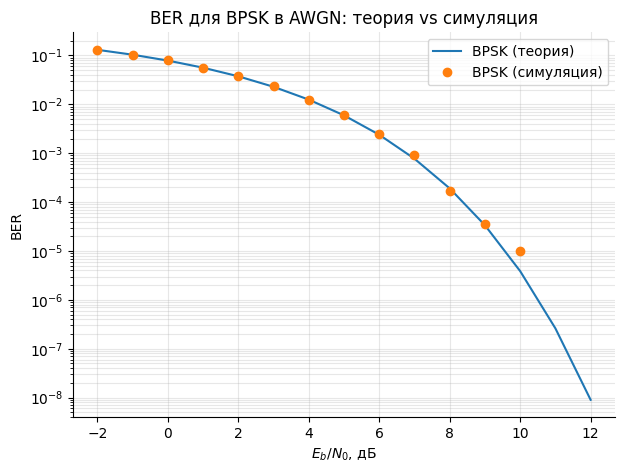

In [8]:
# Сетка Eb/N0 в дБ для эксперимента
EbN0_dB_grid = np.linspace(-2, 12, 15)  # от -2 до 12 дБ

# Теоретический BER
ber_theory = ber_bpsk_awgn_theory(EbN0_dB_grid)

# Эмпирический BER по Монте-Карло
ber_emp = simulate_ber_bpsk_awgn(EbN0_dB_grid, n_bits=int(2e5), seed=42)

# График
fig, ax = plt.subplots()
ax.semilogy(EbN0_dB_grid, ber_theory, label='BPSK (теория)')
ax.semilogy(EbN0_dB_grid, ber_emp, 'o', label='BPSK (симуляция)')

ax.set_xlabel('$E_b/N_0$, дБ')
ax.set_ylabel('BER')
ax.set_title('BER для BPSK в AWGN: теория vs симуляция')
ax.grid(True, which='both')
ax.legend()
plt.show()


В правой части точки хуже совпадают, т к при малой вероятности ошибки статистика становится бедной.

Теперь мы:

- строим гладкую кривую пропускной способности AWGN-канала
  $$
  C_{\text{norm}}(E_b/N_0) = \log_2\bigl(1 + \mathrm{SNR}\bigr)
  $$
  в единицах бит/с/Гц;
- предполагаем режим $R_b = B$, то есть 1 бит в секунду на 1 Гц полосы.  
  В этом режиме
  $$
  \mathrm{SNR} = \frac{E_b}{N_0},
  $$
  поэтому по оси $x$ откладываем именно $E_b/N_0$ в дБ;
- проводим горизонтальную линию на уровне скорости нашей «сырой» схемы:
  $$
  R = 1\ \text{бит/с/Гц};
  $$
- находим точку пересечения $C_{\text{norm}} = R$:
  $$
  1 = \log_2(1 + \mathrm{SNR})
  \;\Rightarrow\;
  \mathrm{SNR} = 2^1 - 1 = 1 \quad\Rightarrow\quad
  E_b/N_0 = 0\ \text{дБ},
  $$
  и отмечаем её вертикальной пунктирной линией как «предел Шеннона» для $R = 1$ бит/с/Гц.

Интерпретация графика:

- слева от $0$ дБ пропускная способность канала **меньше 1 бит/с/Гц**, то есть передать 1 бит/с/Гц с произвольно малой вероятностью ошибки в принципе нельзя — не хватит информативности канала;
- справа от $0$ дБ пропускная способность **выше 1 бит/с/Гц**, и теоретически существует кодирование, позволяющее передавать 1 бит/с/Гц сколь угодно надёжно.

Значение $0$ дБ здесь — это нормальный результат: это именно Шенноновский предел **для спектральной эффективности 1 бит/с/Гц**. Знаменитые $-1{,}59$ дБ относятся к другому режиму — к асимптотическому пределу при скорости, стремящейся к нулю.

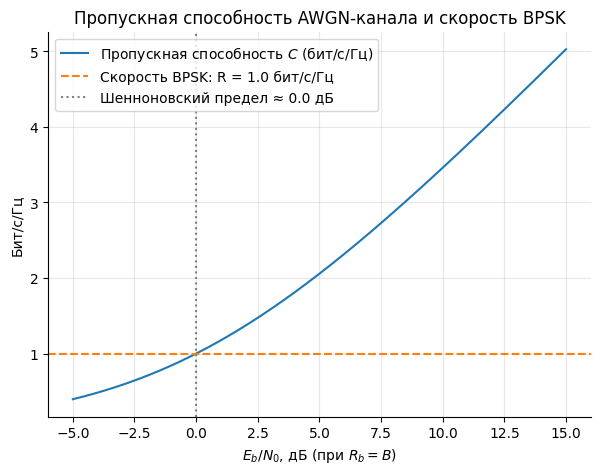

np.float64(0.0)

In [9]:
# Плотная сетка по Eb/N0 для красивой кривой C(Eb/N0)
EbN0_dB_dense = np.linspace(-5, 15, 401)

# Пропускная способность (бит/с/Гц) при Rb/B = 1
C_norm = capacity_awgn_from_ebn0(EbN0_dB_dense, Rb_over_B=1.0)

# Скорость нашей схемы (BPSK без кодирования): 1 бит/с/Гц
R_scheme = 1.0

# Теоретический предел по Eb/N0 для данной скорости:
# решаем log2(1 + SNR) = R_scheme  =>  SNR = 2^R - 1
SNR_limit_lin = 2**R_scheme - 1
EbN0_limit_dB = lin2db(SNR_limit_lin)  # т.к. при Rb/B = 1 SNR = Eb/N0

fig, ax = plt.subplots()
ax.plot(EbN0_dB_dense, C_norm, label='Пропускная способность $C$ (бит/с/Гц)')
ax.axhline(R_scheme, color='C1', linestyle='--', label=f'Скорость BPSK: R = {R_scheme} бит/с/Гц')
ax.axvline(EbN0_limit_dB, color='grey', linestyle=':', label=f'Шенноновский предел ≈ {EbN0_limit_dB:.1f} дБ')

ax.set_xlabel('$E_b/N_0$, дБ (при $R_b = B$)')
ax.set_ylabel('Бит/с/Гц')
ax.set_title('Пропускная способность AWGN-канала и скорость BPSK')
ax.grid(True)
ax.legend()
plt.show()

EbN0_limit_dB


График пропускной способности AWGN-канала иллюстрирует фундаментальное ограничение, накладываемое шумом на скорость передачи информации. Синяя кривая соответствует нормированной пропускной способности канала  
\[
C_{\text{norm}} = \log_2(1 + \mathrm{SNR}),
\]
а горизонтальная линия показывает скорость рассматриваемой схемы передачи — BPSK без кодирования со спектральной эффективностью \(R = 1\) бит/с/Гц.

Точка пересечения этих кривых соответствует шенноновскому пределу для данной скорости передачи. В рассматриваемом режиме \(R_b = B\) этому пределу соответствует значение \(E_b/N_0 \approx 0\) дБ. При меньших значениях \(E_b/N_0\) пропускная способность канала оказывается ниже требуемой скорости, поэтому надёжная передача с вероятностью ошибки, стремящейся к нулю, принципиально невозможна независимо от используемых методов обработки сигнала.  

При \(E_b/N_0 > 0\) дБ пропускная способность превышает 1 бит/с/Гц, и теоретически существуют методы кодирования, позволяющие обеспечить сколь угодно малую вероятность ошибки при передаче с данной скоростью. Однако это утверждение относится к оптимальным кодам большой длины и не означает, что некодированная BPSK достигает этого предела на практике.

Сравнение данного графика с зависимостью BER для некодированной BPSK в AWGN показывает наличие значительного разрыва между реальной схемой передачи и предельными возможностями канала, что подчёркивает роль помехоустойчивого кодирования в приближении к шенноновскому пределу.


In [10]:
import pandas as pd

# Возьмём те же точки, что и для графика BER
EbN0_dB_grid = np.linspace(-2, 12, 15)

# Теоретический BER
ber_theory = ber_bpsk_awgn_theory(EbN0_dB_grid)

# Эмпирический BER
ber_emp = simulate_ber_bpsk_awgn(EbN0_dB_grid, n_bits=int(2e5), seed=42)

# Пропускная способность (нормированная, бит/с/Гц) при Rb/B = 1
C_norm_grid = capacity_awgn_from_ebn0(EbN0_dB_grid, Rb_over_B=1.0)

df = pd.DataFrame({
    "Eb/N0, dB": EbN0_dB_grid,
    "BER (теория)": ber_theory,
    "BER (симуляция)": ber_emp,
    "C_norm (бит/с/Гц)": C_norm_grid,
})

# Округлим числа для более читаемого вывода
df_rounded = df.copy()
df_rounded["BER (теория)"] = df_rounded["BER (теория)"].apply(lambda x: f"{x:.2e}")
df_rounded["BER (симуляция)"] = df_rounded["BER (симуляция)"].apply(lambda x: f"{x:.2e}")
df_rounded["C_norm (бит/с/Гц)"] = df_rounded["C_norm (бит/с/Гц)"].apply(lambda x: f"{x:.3f}")

df_rounded


,"Eb/N0, dB",BER (теория),BER (симуляция),C_norm (бит/с/Гц)
0,-2.0,1.31e-01,1.30e-01,0.706
1,-1.0,1.04e-01,1.04e-01,0.843
2,0.0,7.86e-02,7.91e-02,1.000
3,1.0,5.63e-02,5.62e-02,1.176
4,2.0,3.75e-02,3.81e-02,1.370
5,3.0,2.29e-02,2.33e-02,1.583
6,4.0,1.25e-02,1.26e-02,1.812
7,5.0,5.95e-03,6.02e-03,2.057
8,6.0,2.39e-03,2.48e-03,2.316
9,7.0,7.73e-04,9.35e-04,2.588


Здесь мы для тех же значений $E_b/N_0$ считаем сразу три вещи:

- **теоретический BER** BPSK в AWGN;
- **эмпирический BER** из симуляции;
- **пропускную способность канала** $C_{\text{norm}} = \log_2(1 + \mathrm{SNR})$ (бит/с/Гц) при $R_b/B = 1$.

Из таблицы видно, что:

- теоретический и симуляционный BER практически совпадают (расхождения только на очень малых вероятностях из-за конечного числа бит);
- при $E_b/N_0 = 0$ дБ $C_{\text{norm}} \approx 1$ бит/с/Гц (наш выбранный уровень скорости),  
  а при росте $E_b/N_0$ $C_{\text{norm}}$ быстро превышает 1, и канал **теоретически** может нести больше бит/с/Гц, чем простая BPSK-схема без кодирования.

Шенноновский предел для R = 1.0 бит/с/Гц: Eb/N0 ≈ 0.00 дБ
Для BER ≈ 1e-03 у теоретической BPSK нужно Eb/N0 ≈ 6.80 дБ
Зазор до предела Шеннона (coding/modulation gap) ≈ 6.80 дБ


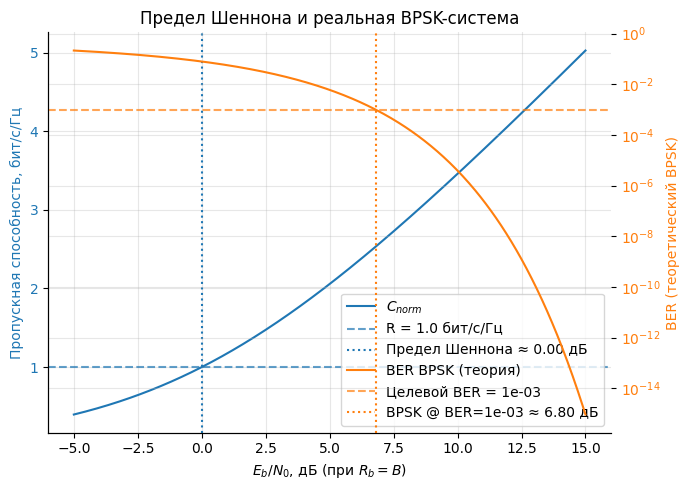

In [ ]:
# Плотная сетка по Eb/N0 для гладких кривых
EbN0_dB_dense = np.linspace(-5, 15, 401)
EbN0_lin_dense = db2lin(EbN0_dB_dense)

# Пропускная способность (бит/с/Гц) при Rb/B = 1
C_norm_dense = capacity_awgn_from_ebn0(EbN0_dB_dense, Rb_over_B=1.0)

# Теоретический BER для плотной сетки
ber_theory_dense = ber_bpsk_awgn_theory(EbN0_dB_dense)

# Скорость нашей "сырой" схемы: BPSK без кодирования → 1 бит/с/Гц
R_scheme = 1.0

# Шенноновский предел по Eb/N0 для R = 1 бит/с/Гц:
# решаем log2(1 + SNR) = R  =>  SNR = 2^R - 1
SNR_limit_lin = 2**R_scheme - 1
EbN0_limit_dB = lin2db(SNR_limit_lin)  # при Rb/B = 1 имеем SNR = Eb/N0

# Целевой BER для практической системы
target_ber = 1e-3

# Находим минимальный Eb/N0, при котором теоретический BER <= target_ber
mask_ok = ber_theory_dense <= target_ber
if np.any(mask_ok):
    EbN0_req_dB = EbN0_dB_dense[mask_ok][0]
else:
    EbN0_req_dB = np.nan  # если наша сетка не дошла до нужного BER

gap_dB = EbN0_req_dB - EbN0_limit_dB

print(f"Шенноновский предел для R = {R_scheme} бит/с/Гц: Eb/N0 ≈ {EbN0_limit_dB:.2f} дБ")
print(f"Для BER ≈ {target_ber:.0e} у теоретической BPSK нужно Eb/N0 ≈ {EbN0_req_dB:.2f} дБ")
print(f'Зазор до предела Шеннона (coding/modulation gap) ≈ {gap_dB:.2f} дБ')

# Нарисуем картинку с пояснениями
fig, ax1 = plt.subplots()

color_capacity = 'C0'
color_ber = 'C1'

# Левая ось: пропускная способность
ax1.set_xlabel('$E_b/N_0$, дБ (при $R_b = B$)')
ax1.set_ylabel('Пропускная способность, бит/с/Гц', color=color_capacity)
ax1.plot(EbN0_dB_dense, C_norm_dense, color=color_capacity, label='$C_{norm}$')
ax1.axhline(R_scheme, color=color_capacity, linestyle='--', alpha=0.7,
            label=f'R = {R_scheme} бит/с/Гц')
ax1.axvline(EbN0_limit_dB, color=color_capacity, linestyle=':',
            label=f'Предел Шеннона ≈ {EbN0_limit_dB:.2f} дБ')
ax1.tick_params(axis='y', labelcolor=color_capacity)

# Правая ось: BER (логарифмическая шкала)
ax2 = ax1.twinx()
ax2.set_ylabel('BER (теоретический BPSK)', color=color_ber)
ax2.semilogy(EbN0_dB_dense, ber_theory_dense, color=color_ber,
             label='BER BPSK (теория)')
ax2.axhline(target_ber, color=color_ber, linestyle='--', alpha=0.7,
            label=f'Целевой BER = {target_ber:.0e}')
ax2.axvline(EbN0_req_dB, color=color_ber, linestyle=':',
            label=f'BPSK @ BER={target_ber:.0e} ≈ {EbN0_req_dB:.2f} дБ')
ax2.tick_params(axis='y', labelcolor=color_ber)

# Объединённая легенда
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

ax1.grid(True, which='both', axis='both')
ax1.set_title('Предел Шеннона и реальная BPSK-система')

plt.tight_layout()
plt.show()


**Предел Шеннона и «зазор» реальной BPSK-системы**

Cмотрим на две вещи:

- **Пропускную способность AWGN-канала**
  $$
  C_{\text{norm}}(E_b/N_0) = \log_2\bigl(1 + \mathrm{SNR}\bigr),
  \quad \mathrm{SNR} = E_b/N_0 \text{ при } R_b = B
  $$
  (левая ось, синяя кривая).
- **Теоретический BER BPSK**
  $$
  P_b(E_b/N_0) = Q\!\left(\sqrt{2\,E_b/N_0}\right)
  $$
  (правая ось, оранжевая кривая в логарифмическом масштабе).

Дальше мы:

- фиксируем скорость схемы без кодирования  
  $$R = 1\ \text{бит/с/Гц}$$
  и проводим горизонтальную линию на этом уровне;
- находим **предел Шеннона** для такой скорости:
  $$
  R = \log_2(1 + \mathrm{SNR}) = 1
  \;\Rightarrow\;
  \mathrm{SNR} = 1
  \;\Rightarrow\;
  E_b/N_0 \approx 0\ \text{дБ},
  $$
  отмечаем его вертикальной синей линией;
- задаём целевой уровень надёжности
  $$P_b = 10^{-3}$$
  и по кривой BER BPSK находим нужный
  $$E_b/N_0 \approx 6{.}8\ \text{дБ},$$
  отмечаем второй вертикальной (оранжевой) линией.

Из вывода :

- предел Шеннона для \(R = 1\) бит/с/Гц: \(E_b/N_0 \approx 0\) дБ;
- для достижения \(P_b \approx 10^{-3}\) у BPSK требуется \(E_b/N_0 \approx 6{.}8\) дБ;

то есть **реальная некодированная BPSK-система работает примерно на 7 дБ дальше от предела Шеннона**, чем идеально закодированный канал при той же скорости.


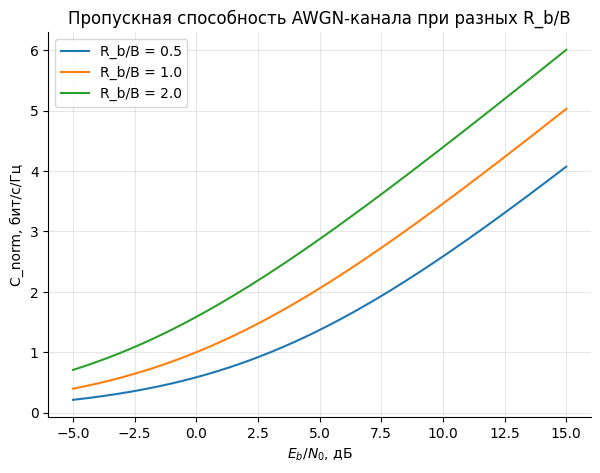

In [ ]:
Rb_over_B_list = [0.5, 1.0, 2.0]

fig, ax = plt.subplots()

for Rb_over_B in Rb_over_B_list:
    C_norm_curr = capacity_awgn_from_ebn0(EbN0_dB_dense, Rb_over_B=Rb_over_B)
    ax.plot(EbN0_dB_dense, C_norm_curr, label=f'R_b/B = {Rb_over_B}')

ax.set_xlabel('$E_b/N_0$, дБ')
ax.set_ylabel('C_norm, бит/с/Гц')
ax.set_title('Пропускная способность AWGN-канала при разных R_b/B')
ax.grid(True)
ax.legend()
plt.show()


**Влияние отношения $R_b/B$ на пропускную способность**

Считаем нормированную пропускную способность AWGN-канала
$$
C_{\text{norm}} = \log_2\bigl(1 + \mathrm{SNR}\bigr),
\qquad
\mathrm{SNR} = \frac{E_b}{N_0}\,\frac{R_b}{B},
$$
для трёх вариантов отношения $R_b/B = 0.5,\ 1,\ 2$.

С ростом $R_b/B$:

- при том же $E_b/N_0$ SNR становится больше, поэтому кривая $C_{\text{norm}}(E_b/N_0)$ поднимается выше;
- это означает, что **чем выше требуемая спектральная эффективность $R_b/B$**, тем сильнее приходится повышать $E_b/N_0$, чтобы оставаться вблизи границы Шеннона.

## **Результаты и применимость**

### Краткие выводы экспериментов

- Для канала AWGN с BPSK теоретическая формула  
  $ P_b = Q\!\left(\sqrt{2\,E_b/N_0}\right) $
  почти идеально совпала с эмпирическим BER по Монте-Карло — модель и симуляция согласованы.

- Пропускная способность AWGN-канала растёт по закону  
  $ C_{\text{norm}} = \log_2\bigl(1 + \mathrm{SNR}\bigr) $
  и при $ E_b/N_0 = 0 \text{ дБ} $ (и $R_b = B$) даёт примерно $1$ бит/с/Гц — это «точка Шеннона» для скорости 1 бит/с/Гц.

- Некодированная BPSK-система, чтобы обеспечить целевой $\text{BER} \approx 10^{-3}$, требует около  
  $E_b/N_0 \approx 6{.}8 \text{ дБ},$
  то есть работает примерно на $6{.}8 \text{ дБ}$ хуже теоретического предела Шеннона при той же скорости.

- При увеличении отношения $$R_b/B$$ (бит/с на 1 Гц полосы) кривая $C_{\text{norm}}(E_b/N_0)$ поднимается выше: чем выше спектральная эффективность, тем больший запас по $E_b/N_0$ нужен, чтобы оставаться вблизи предела Шеннона.

---

### Как это можно использовать

- **Планирование линк-бюджета.**  
  По кривой $C_{\text{norm}}(E_b/N_0)$ можно оценить, возможна ли вообще заданная скорость (бит/с/Гц) при ожидаемом SNR. Если требуемая скорость выше пропускной способности, никакое кодирование уже не спасёт.

- **Оценка запаса до предела Шеннона.**  
  Разница в несколько дБ между реальной схемой (BPSK без кода) и пределом показывает, какой «coding gain» теоретически можно выжать с помощью более продвинутых кодов и модуляций.

- **Выбор модуляции и кода.**  
  Зная, при каком $E_b/N_0$ конкретная схема даёт нужный BER, можно строить лестницу MCS (BPSK/QPSK/16QAM + разные коды) и переключаться между ними в зависимости от измеренного SNR, чтобы работать как можно ближе к границе Шеннона.

- **Анализ эффективности спектра.**  
  Графики для разных $R_b/B$ показывают цену высокой спектральной эффективности: за каждый дополнительный бит/с/Гц приходится платить ростом требуемого $E_b/N_0$. Это напрямую связано с дизайном современных широкополосных систем (LTE/5G/Wi-Fi).

Модель AWGN-канала с BPSK проста, но она даёт наглядную и количественную связь между $E_b/N_0$, BER и пределом Шеннона, которая лежит в основе проектирования реальных радиолиний и выбора параметров модуляции/кодирования.

## **Литература**

1. [Статья на Хабр (JetBrains Education) о теореме Шеннона–Хартли](https://habr.com/ru/companies/JetBrains-education/articles/599637/)
2. [Теорема Шеннона — Хартли (Wikipedia)](https://ru.wikipedia.org/wiki/Теорема_Шеннона_—_Хартли)
3. [Аддитивный белый гауссовский шум (Wikipedia)](https://ru.wikipedia.org/wiki/Аддитивный_белый_гауссовский_шум)
4. [Спектральная плотность мощности (Wikipedia)](https://ru.wikipedia.org/wiki/Спектральная_плотность_мощности)
5. [Нормальное распределение (Wikipedia)](https://ru.wikipedia.org/wiki/Нормальное_распределение)
6. [Пропускная способность канала (Wikipedia)](https://ru.wikipedia.org/wiki/Пропускная_способность_канала)
7. [Отношение сигнал/шум (Wikipedia)](https://ru.wikipedia.org/wiki/Eb/N0)
8. [Пропускная способность канала (Wikipedia)](https://ru.wikipedia.org/wiki/Пропускная_способность_канала)

